<a href="https://colab.research.google.com/github/Bavesh-08/customer-segmentation-using-kmeans/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing the dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder


In [ ]:
# loding the dataset

customer_data=pd.read_csv('/content/customer_segmentation_data.csv')


In [ ]:
# printing the first five rows of the dataset

customer_data.head()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2


In [ ]:
#removing the segmention column from the dataset

customer_data.drop('Segmentation Group',axis=1,inplace=True)

In [ ]:
# finding the number of rows and column

customer_data.shape

(53503, 19)

In [ ]:
# getting info from the dataset

customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  object
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Geographic Information              53503 non-null  object
 6   Occupation                          53503 non-null  object
 7   Income Level                        53503 non-null  int64 
 8   Behavioral Data                     53503 non-null  object
 9   Purchase History                    53503 non-null  object
 10  Interactions with Customer Service  53503 non-null  object
 11  Insurance Products Owned            53503 non-null  ob

In [ ]:
# finding null valuse

customer_data.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Marital Status,0
Education Level,0
Geographic Information,0
Occupation,0
Income Level,0
Behavioral Data,0
Purchase History,0


In [ ]:
# label encoding

object_cols = customer_data.select_dtypes(include='object').columns


for col in object_cols:
    le = LabelEncoder()
    customer_data[col] = le.fit_transform(customer_data[col])
    print(f"Column '{col}' label encoded.")

Column 'Gender' label encoded.
Column 'Marital Status' label encoded.
Column 'Education Level' label encoded.
Column 'Geographic Information' label encoded.
Column 'Occupation' label encoded.
Column 'Behavioral Data' label encoded.
Column 'Purchase History' label encoded.
Column 'Interactions with Customer Service' label encoded.
Column 'Insurance Products Owned' label encoded.
Column 'Policy Type' label encoded.
Column 'Customer Preferences' label encoded.
Column 'Preferred Communication Channel' label encoded.
Column 'Preferred Contact Time' label encoded.
Column 'Preferred Language' label encoded.


In [ ]:
# now getting info from the dataset

customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Customer ID                         53503 non-null  int64
 1   Age                                 53503 non-null  int64
 2   Gender                              53503 non-null  int64
 3   Marital Status                      53503 non-null  int64
 4   Education Level                     53503 non-null  int64
 5   Geographic Information              53503 non-null  int64
 6   Occupation                          53503 non-null  int64
 7   Income Level                        53503 non-null  int64
 8   Behavioral Data                     53503 non-null  int64
 9   Purchase History                    53503 non-null  int64
 10  Interactions with Customer Service  53503 non-null  int64
 11  Insurance Products Owned            53503 non-null  int64
 12  Cove

In [ ]:
# finding the wcss for different number of clusters

wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(customer_data)
  wcss.append(kmeans.inertia_)



<function matplotlib.pyplot.show(close=None, block=None)>

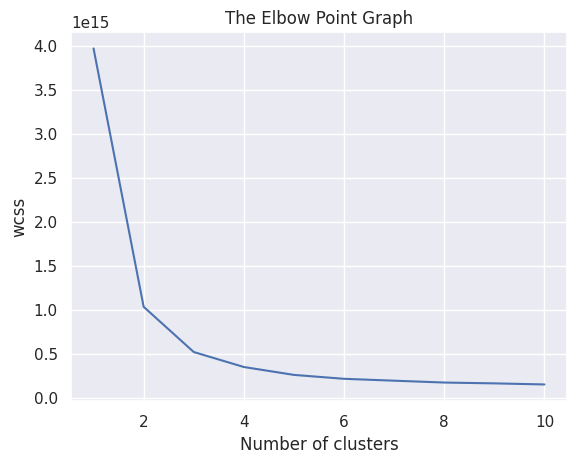

In [ ]:
# ploting the elbow graph for the wscc values

sns.set()
plt.plot(range(1,11),wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of clusters')
plt.ylabel('wcss')
plt.show

In [ ]:
# there are there significant drops therefore we can make 4 cluster

# traning the k means clustring model

kmeans=KMeans(n_clusters=4,init='k-means++',random_state=42)


In [ ]:
# returing the label for each clusters

y=kmeans.fit_predict(customer_data)
print(y)

[2 0 0 ... 3 0 0]


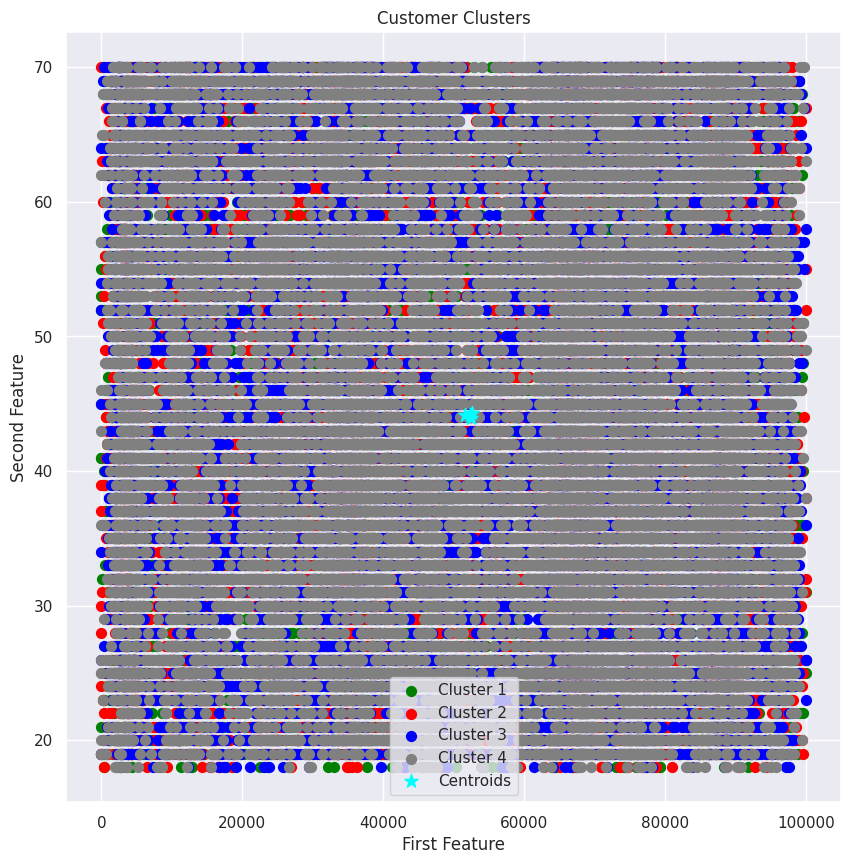

In [ ]:
# visulazation of all this clusters and their centroid

plt.figure(figsize=(20,20))

# Plotting the clusters
plt.scatter(customer_data.iloc[y == 0, 0], customer_data.iloc[y == 0, 1], s = 50, c = 'green', label = 'Cluster 1')
plt.scatter(customer_data.iloc[y == 1, 0], customer_data.iloc[y == 1, 1], s = 50, c = 'red', label = 'Cluster 2')
plt.scatter(customer_data.iloc[y == 2, 0], customer_data.iloc[y == 2, 1], s = 50, c = 'blue', label = 'Cluster 3')
plt.scatter(customer_data.iloc[y == 3, 0], customer_data.iloc[y == 3, 1], s = 50, c = 'gray', label = 'Cluster 4')

# Plotting the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'cyan', label = 'Centroids', marker='*')

plt.title('Customer Clusters')
plt.xlabel('First Feature')
plt.ylabel('Second Feature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.decomposition import PCA

# Create a copy of the dataframe and add the cluster labels
clustered_data = customer_data.copy()
clustered_data['Cluster'] = y

# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)

# Fit PCA and transform the original customer data (without the cluster column)
pca_features = pca.fit_transform(customer_data)

# Add the principal components to the clustered_data DataFrame
clustered_data['PCA_Feature_1'] = pca_features[:, 0]
clustered_data['PCA_Feature_2'] = pca_features[:, 1]

# Get centroids in the PCA space
# First, transform the original centroids into the PCA space
pca_centroids = pca.transform(kmeans.cluster_centers_)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


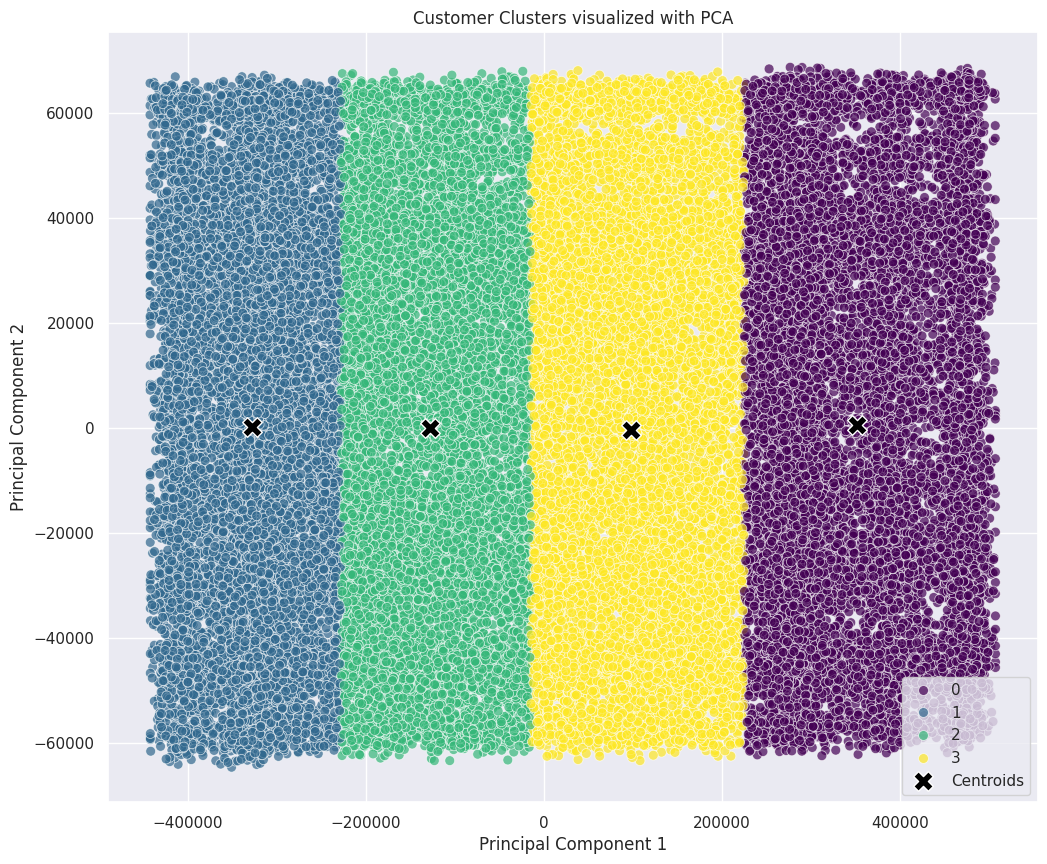

In [ ]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='PCA_Feature_1',
    y='PCA_Feature_2',
    hue='Cluster',
    data=clustered_data,
    palette='viridis',
    s=50,
    alpha=0.7
)

# Plotting the centroids
plt.scatter(
    pca_centroids[:, 0],
    pca_centroids[:, 1],
    s = 200,
    c = 'black',
    marker='X',
    label = 'Centroids',
    edgecolor='white',
    linewidth=1
)

plt.title('Customer Clusters visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

This visualization uses the first two principal components to represent your customer data in a 2D space. Each point is a customer, colored by its assigned cluster. The black 'X' marks represent the centroids of these clusters in the PCA-transformed space. This approach helps in understanding the separation and distribution of clusters when dealing with many original features.